In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ERA5_path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'

In [3]:
RH = xr.open_dataset(ERA5_path+'RH_during_peak_HI.nc')
T  = xr.open_dataset(ERA5_path+'T_during_peak_HI.nc')
U  = xr.open_dataset(ERA5_path+'U10_during_peak_HI.nc')
V  = xr.open_dataset(ERA5_path+'V10_during_peak_HI.nc')
HI_dmax = xr.open_dataset(ERA5_path+'dailymax_HI.nc')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
idate = '1940-01-01'
fdate = '2025-12-31'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
RH = RH['RH_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['T_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U_during_HIdmax'].sel(time=slice(idate, fdate))
V = V['V_during_HIdmax'].sel(time=slice(idate, fdate))

In [5]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 2GB
Dimensions:          (latitude: 82, longitude: 121, time: 31412)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 251kB 1940-01-01 ... 2025-12-31
Data variables:
    U_during_HIdmax  (time, latitude, longitude) float32 1GB ...
    V_during_HIdmax  (time, latitude, longitude) float32 1GB ...

# monthly means

In [6]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

In [7]:
def C_to_F(t):
    F_ds = (t * 9/5) + 32
    return F_ds


def K_to_C(t):
    return (t - 273.15)

In [8]:
meT = C_to_F(K_to_C(meT))
meT

<xarray.DataArray 'T_during_HIdmax' (time: 1032, latitude: 82, longitude: 121)> Size: 41MB
array([[[78.97886 , 79.0501  , 79.127174, ..., 83.68013 , 82.67471 ,
         80.935524],
        [78.58615 , 78.6953  , 78.80071 , ..., 82.5927  , 80.81044 ,
         79.426605],
        [78.226456, 78.32402 , 78.46305 , ..., 79.80239 , 79.37239 ,
         79.497795],
        ...,
        [64.688774, 64.78084 , 64.82863 , ..., 71.459816, 71.45026 ,
         71.471954],
        [63.85546 , 63.89084 , 63.91704 , ..., 71.12956 , 71.07392 ,
         71.073204],
        [63.01891 , 63.04489 , 63.013855, ..., 70.8108  , 70.75762 ,
         70.7557  ]],

       [[80.35358 , 80.37258 , 80.400925, ..., 86.15826 , 84.57106 ,
         81.95116 ],
        [80.0136  , 80.07914 , 80.12693 , ..., 84.05899 , 81.69243 ,
         79.21671 ],
        [79.69594 , 79.74598 , 79.817665, ..., 80.345665, 79.16853 ,
         79.32163 ],
...
        [74.42876 , 74.42601 , 74.506874, ..., 78.07232 , 78.07216 ,
         78.08303 ],
        [74.186676, 74.143776, 74.277756, ..., 77.99761 , 78.0264  ,
         78.03277 ],
        [73.95953 , 73.8745  , 73.96992 , ..., 77.84914 , 77.91631 ,
         77.98822 ]],

       [[79.4883  , 79.61063 , 79.75894 , ..., 84.66835 , 83.9878  ,
         82.46202 ],
        [79.38936 , 79.52164 , 79.68693 , ..., 83.9644  , 82.290794,
         80.60901 ],
        [79.290596, 79.45451 , 79.63875 , ..., 81.3986  , 80.749306,
         80.89125 ],
        ...,
        [73.48295 , 73.461525, 73.46367 , ..., 76.59263 , 76.50215 ,
         76.5255  ],
        [73.11304 , 73.11925 , 73.1689  , ..., 76.429535, 76.38542 ,
         76.33967 ],
        [72.7222  , 72.73016 , 72.76845 , ..., 76.298744, 76.29133 ,
         76.25655 ]]], shape=(1032, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2025-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

# ERS selection

In [9]:
ERS = [4, 5, 6, 7]
ERS_HI = meHI_dmax.where(meHI_dmax.time.dt.month.isin(ERS), drop=True)
ERS_RH = meRH.where(meRH.time.dt.month.isin(ERS), drop=True)
ERS_T = meT.where(meT.time.dt.month.isin(ERS), drop=True)
ERS_UV = meUV.where(meUV.time.dt.month.isin(ERS), drop=True)

## HI and UV

In [10]:
ERS_HIme = ERS_HI.mean('time')
ERS_RHme = ERS_RH.mean('time')
ERS_Tme = ERS_T.mean('time')
ERS_UVme = ERS_UV.mean('time')

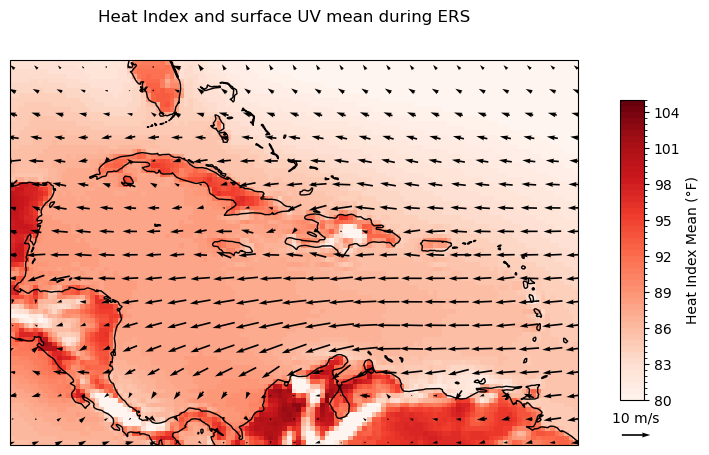

In [11]:
ERS_HIme_plot = ERS_HIme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(80, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=200)

ERS_HIme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_HIme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HIme_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Heat Index and surface UV mean during ERS')
plt.show()

### RH

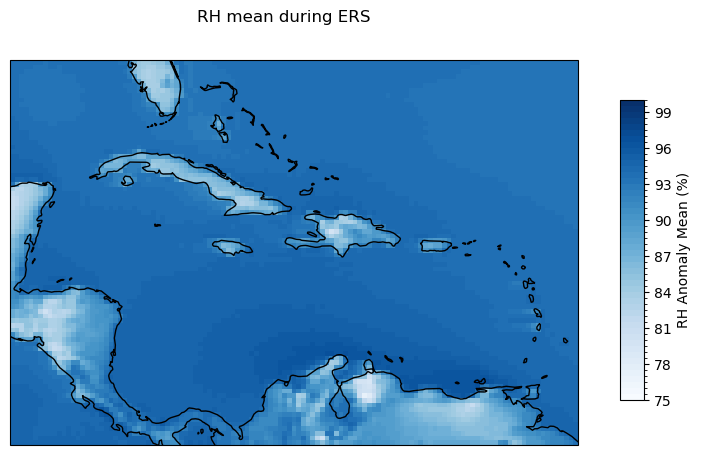

In [12]:
ERS_RHme_plot = ERS_RHme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(75, 100.5, 0.5), colors='Blues', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

ERS_RHme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_RHme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RHme_plot, cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('RH mean during ERS')
plt.show()

### T

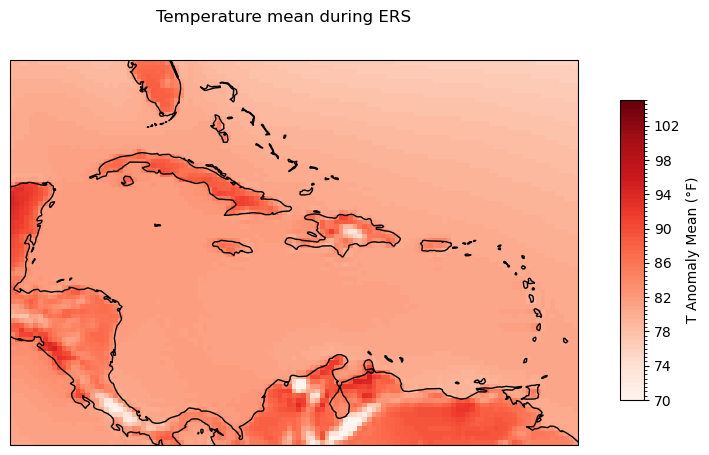

In [13]:
ERS_Tme_plot = ERS_Tme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(70, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

ERS_Tme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = ERS_Tme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_Tme_plot, cax=cax, label='T Anomaly Mean (°F)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Temperature mean during ERS')
plt.show()

# LRS

In [14]:
LRS = [8, 9, 10, 11]
LRS_HI = meHI_dmax.where(meHI_dmax.time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)

In [15]:
LRS_HIme = LRS_HI.mean('time')
LRS_RHme = LRS_RH.mean('time')
LRS_Tme = LRS_T.mean('time')
LRS_UVme = LRS_UV.mean('time')

## HI and UV

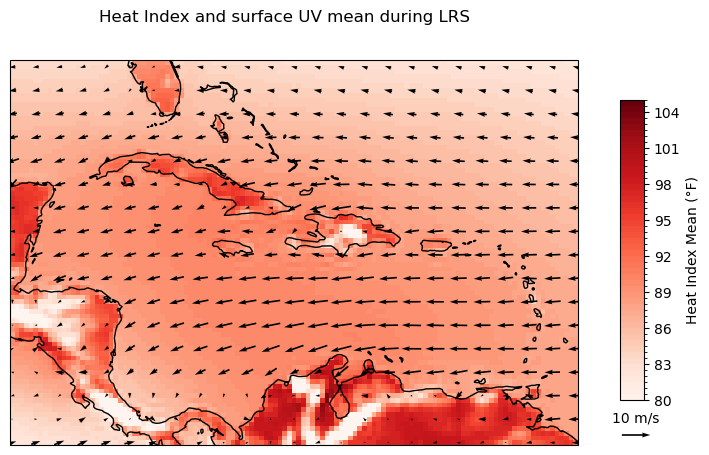

In [19]:
LRS_HIme_plot = LRS_HIme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(80, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

UV_coarse = LRS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=200)

LRS_HIme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_HIme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HIme_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=10, label='10 m/s', labelpos='N', coordinates='figure')

plt.suptitle('Heat Index and surface UV mean during LRS')
plt.show()

## RH

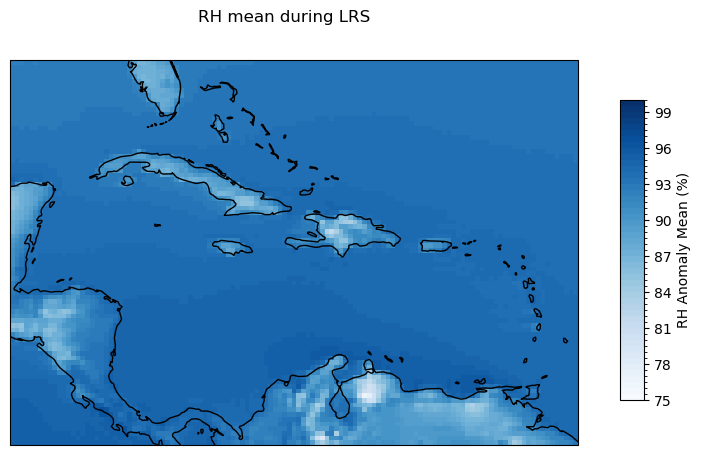

In [17]:
LRS_RHme_plot = LRS_RHme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(75, 100.5, 0.5), colors='Blues', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

LRS_RHme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_RHme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RHme_plot, cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')
plt.suptitle('RH mean during LRS')
plt.show()

## T

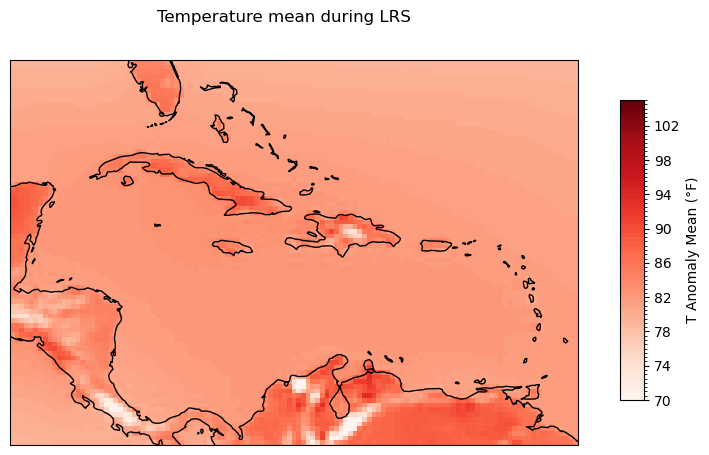

In [18]:
LRS_Tme_plot = LRS_Tme.plot(figsize=(8, 5), add_colorbar=False, levels=np.arange(70, 105.5, 0.5), colors='Reds', subplot_kws={'projection': ccrs.PlateCarree()})

# UV_coarse = ERS_UVme.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
# UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U_during_HIdmax', v='V_during_HIdmax', transform=ccrs.PlateCarree(), add_guide=False, scale=190)

LRS_Tme_plot.axes.coastlines(transform=ccrs.PlateCarree())

fig = LRS_Tme_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_Tme_plot, cax=cax, label='T Anomaly Mean (°F)', orientation='vertical', extend='neither')
# plt.quiverkey(UV_q, X=0.94, Y=0.15, U=10, label='10 m/s', labelpos='N', coordinates='figure')
plt.suptitle('Temperature mean during LRS')
plt.show()